## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)

from src.model_functions import build_lstm_sequences, split_temporal, generate_lstm_model, smape

%matplotlib inline

In [4]:
tickers = ['RENT3', 'LREN3', 'SMFT3', 'ABEV3']

In [5]:
tabela_hiperparams = pd.read_excel("dados/refined/tabela_melhores_hiperparametros.xlsx")

features = [
    'close', 'high', 'low', 'open', 'volume',
    'close_dolar', 'close_ibovespa', 'close_sp_500', 'selic', 'ipca',
    'ma20', 'ma50', 'bb_upper', 'bb_lower', 'rsi_wilder', 'macd',
    'macd_signal', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos'
]

  0%|          | 0/4 [00:00<?, ?it/s]

Processando para RENT3


2026-07-10 20:00:34.447666: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-07-10 20:00:34.447793: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-07-10 20:00:34.448488: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-07-10 20:00:34.448537: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-10 20:00:34.448992: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-10 20:00:35.440749: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


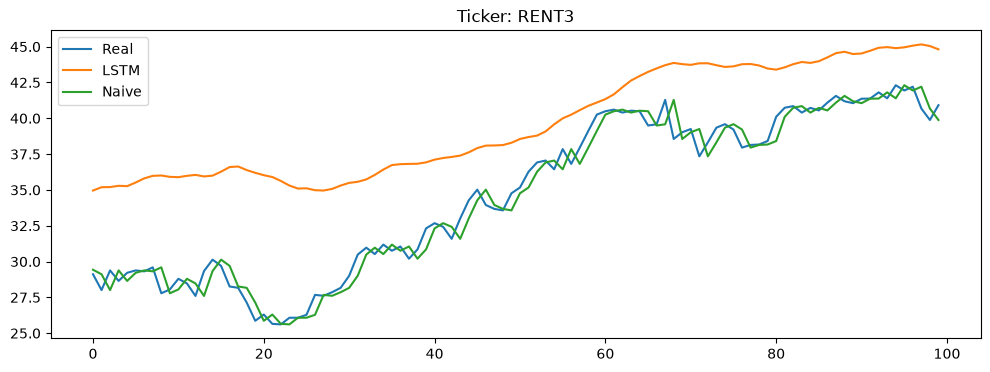

 25%|██▌       | 1/4 [01:17<03:52, 77.64s/it]

Processando para LREN3


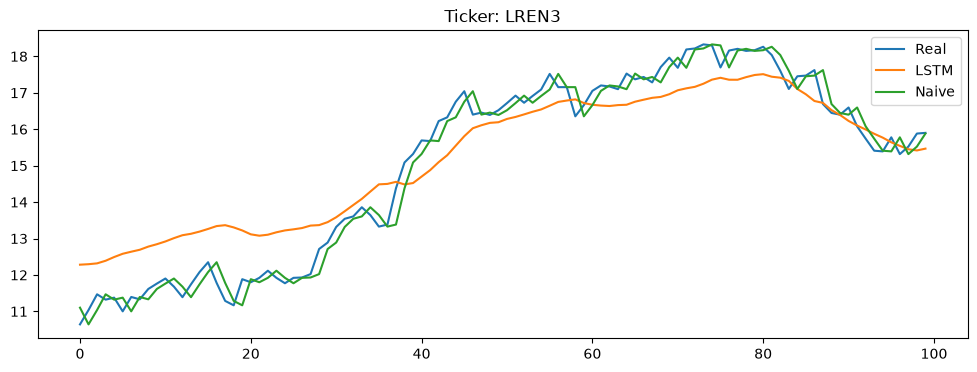

 50%|█████     | 2/4 [01:52<01:44, 52.19s/it]

Processando para SMFT3


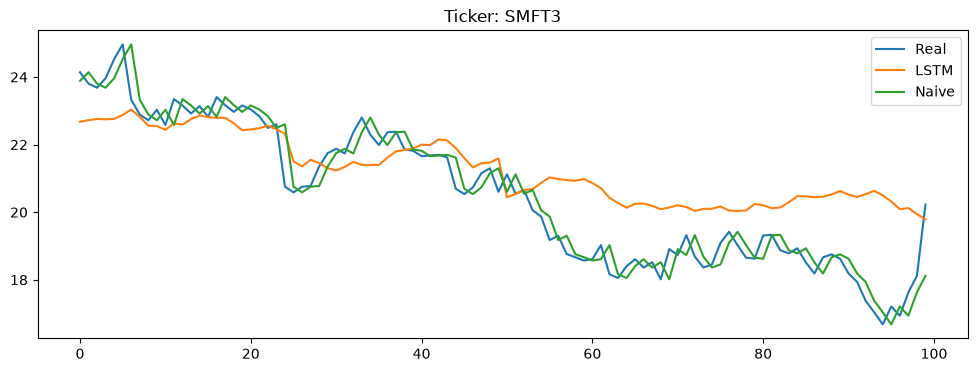

 75%|███████▌  | 3/4 [02:27<00:44, 44.69s/it]

Processando para ABEV3


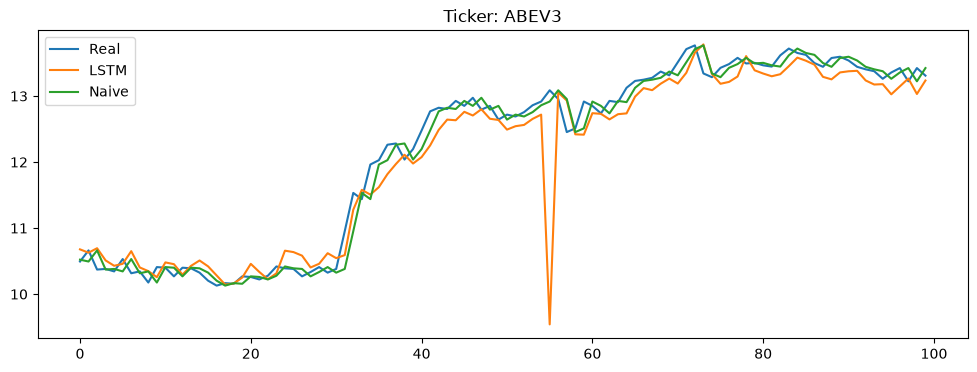

100%|██████████| 4/4 [03:55<00:00, 58.98s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
3,ABEV3,12.42,12.29,1.57,12.60,0.23,0.37,1.70,1.73,0.95,0.14,0.22,1.04,-0.72,1.87,2.99,False
2,SMFT3,18.75,19.32,3.83,20.42,1.20,1.46,6.24,5.99,0.47,0.37,0.50,1.85,-1.91,6.38,7.80,False
1,LREN3,19.60,17.86,6.84,34.89,0.89,1.07,6.36,6.10,0.56,0.27,0.35,1.85,-2.10,4.55,5.47,False
0,RENT3,36.56,39.26,14.61,39.95,3.71,4.34,10.51,9.76,0.52,0.74,1.00,1.88,-3.35,10.14,11.86,False


In [6]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df.dropna()
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss_mse']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v
    recurrent_dropout = 0

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # Divisão temporal ANTES do scaler (evita data leakage)
    n = len(data)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    scaler = RobustScaler()
    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    X_train, y_train = build_lstm_sequences(window_size, train_scaled)
    X_valid, y_valid = build_lstm_sequences(window_size, valid_scaled)
    X_test, y_test = build_lstm_sequences(window_size, test_scaled)

    model = generate_lstm_model(units_1, dropout, units_2, learning_rate, recurrent_dropout, l2, n_dense, dense_units, optimizer, X_train)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=500,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    model.save(f"models/lstm_{ticker}.keras")

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

    plt.figure(figsize=(12,4))

    plt.plot(real[:100], label="Real")
    plt.plot(pred[:100], label="LSTM")
    plt.plot(naive[:100], label="Naive")
    plt.title(f'Ticker: {ticker}')

    plt.legend()
    plt.show()

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
resultado_final.to_excel(
    "dados/refined/resultado_modelos_lstm_3.xlsx",
    index=False
)

## Testar com optimizer e window size fixos

  0%|          | 0/4 [00:00<?, ?it/s]

Processando para RENT3


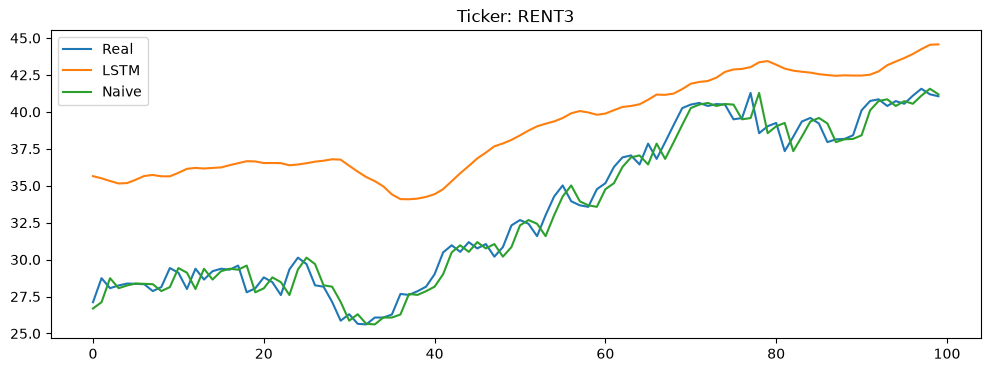

 25%|██▌       | 1/4 [01:46<05:19, 106.34s/it]

Processando para LREN3


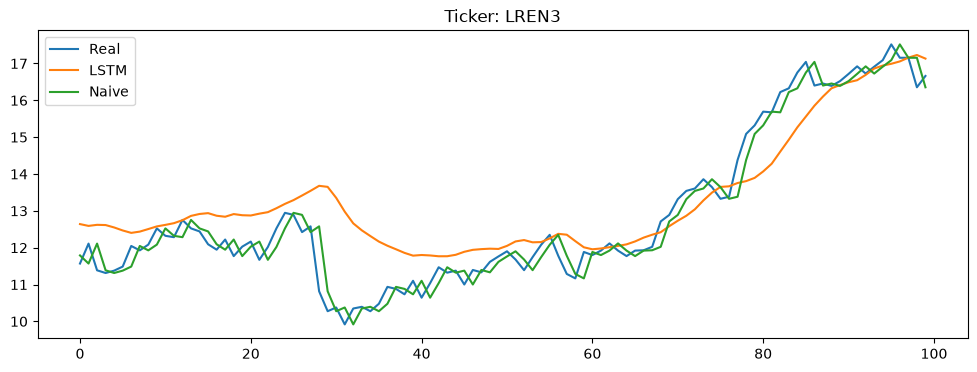

 50%|█████     | 2/4 [02:10<01:56, 58.20s/it] 

Processando para SMFT3


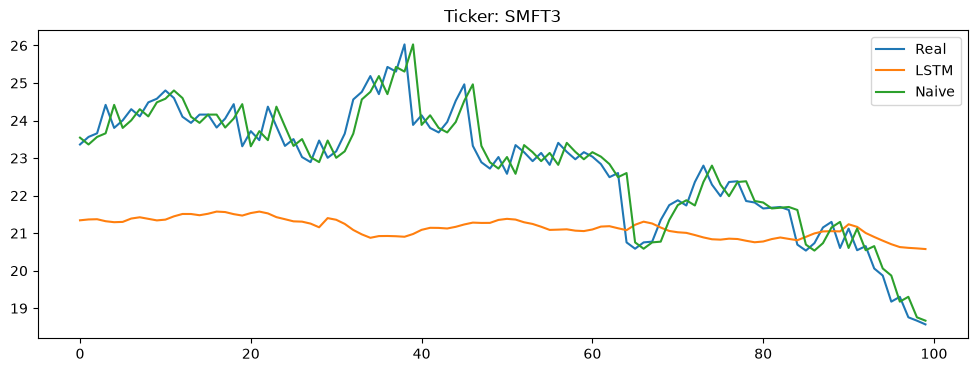

 75%|███████▌  | 3/4 [02:51<00:50, 50.36s/it]

Processando para ABEV3


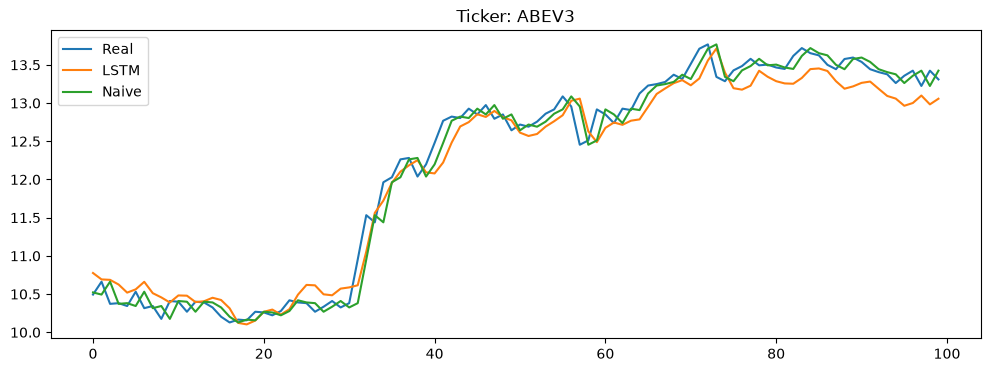

100%|██████████| 4/4 [03:32<00:00, 53.21s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
3,ABEV3,12.42,12.29,1.57,12.60,0.31,0.45,2.23,2.27,0.93,0.14,0.22,1.04,-1.07,2.53,3.59,False
1,LREN3,19.60,17.86,6.84,34.89,0.58,0.77,4.29,4.22,0.82,0.27,0.36,1.96,-1.14,2.95,3.91,False
2,SMFT3,18.75,19.32,3.83,20.42,1.80,2.05,8.39,8.49,0.27,0.39,0.52,1.83,-2.95,9.62,10.96,False
0,RENT3,36.56,39.26,14.61,39.95,4.51,5.04,12.80,11.77,0.38,0.74,0.99,1.88,-4.09,12.34,13.79,False


In [8]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df.dropna()
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss_mse']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v
    recurrent_dropout = 0
    optimizer = 'Adam'
    window_size = 20

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # Divisão temporal ANTES do scaler (evita data leakage)
    n = len(data)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    scaler = RobustScaler()
    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    X_train, y_train = build_lstm_sequences(window_size, train_scaled)
    X_valid, y_valid = build_lstm_sequences(window_size, valid_scaled)
    X_test, y_test = build_lstm_sequences(window_size, test_scaled)

    model = generate_lstm_model(units_1, dropout, units_2, learning_rate, recurrent_dropout, l2, n_dense, dense_units, optimizer, X_train)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=500,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    model.save(f"models/lstm_{ticker}_adam_w20.keras")

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

    plt.figure(figsize=(12,4))

    plt.plot(real[:100], label="Real")
    plt.plot(pred[:100], label="LSTM")
    plt.plot(naive[:100], label="Naive")
    plt.title(f'Ticker: {ticker}')

    plt.legend()
    plt.show()

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
resultado_final.to_excel(
    "dados/refined/resultado_modelos_lstm_adam_w20.xlsx",
    index=False
)

## Testar com período menor de dados

  0%|          | 0/4 [00:00<?, ?it/s]

Processando para RENT3


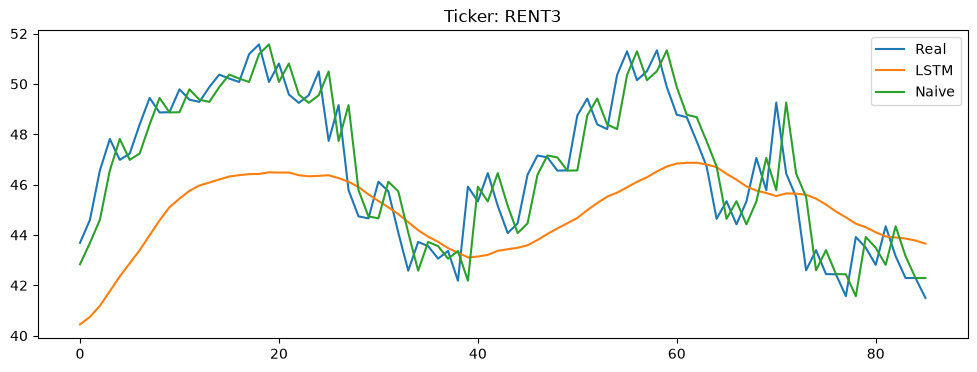

 25%|██▌       | 1/4 [00:32<01:37, 32.51s/it]

Processando para LREN3


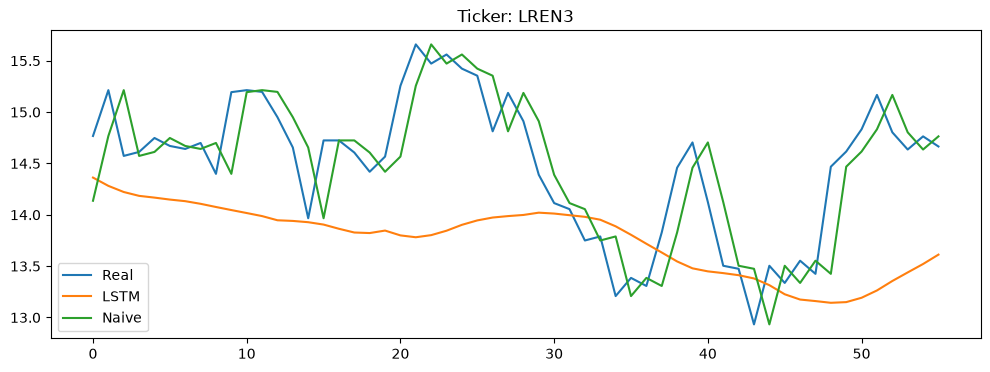

 50%|█████     | 2/4 [00:50<00:48, 24.15s/it]

Processando para SMFT3


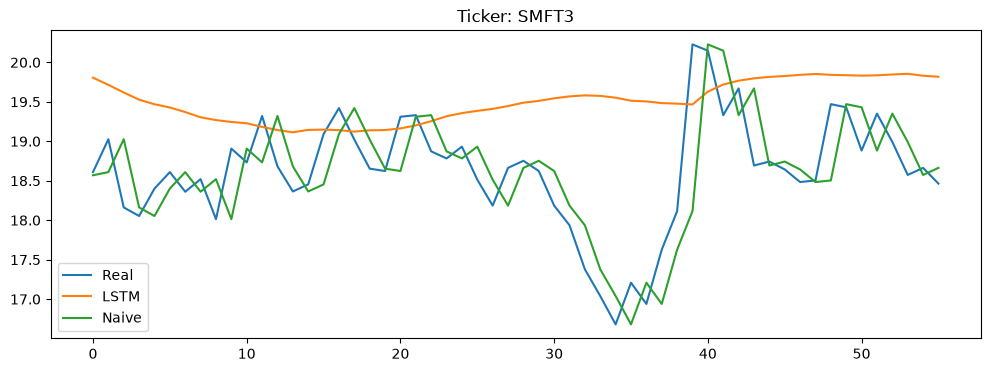

 75%|███████▌  | 3/4 [01:23<00:28, 28.26s/it]

Processando para ABEV3


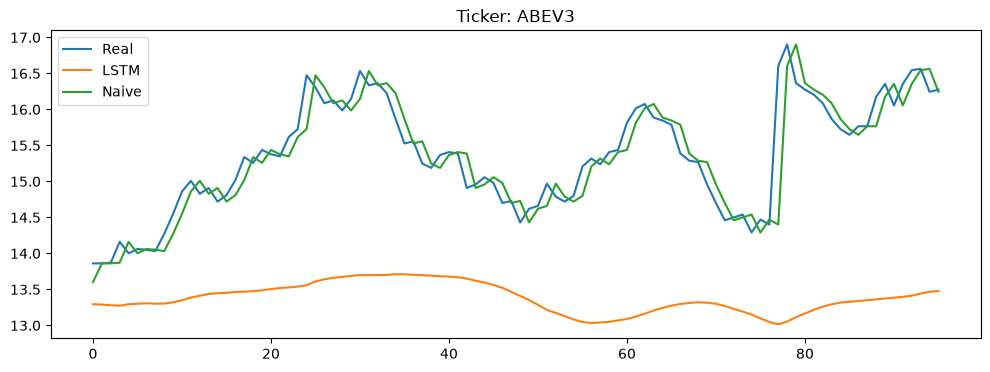

100%|██████████| 4/4 [01:38<00:00, 24.59s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
2,SMFT3,20.76,20.67,2.38,11.45,0.96,1.16,5.27,5.07,-1.72,0.39,0.52,2.09,-1.23,4.61,5.57,False
0,RENT3,43.18,42.18,8.54,19.79,2.58,3.03,5.42,5.58,-0.15,1.03,1.31,2.23,-1.31,5.98,7.01,False
1,LREN3,13.52,13.52,1.93,14.27,0.80,0.95,5.38,5.58,-1.01,0.31,0.39,2.13,-1.42,5.89,7.04,False
3,ABEV3,12.20,11.84,1.51,12.38,1.97,2.11,12.64,13.60,-6.72,0.19,0.31,1.25,-5.71,16.15,17.25,False


In [9]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df.dropna()
    df = df[df['date'] >= pd.to_datetime('2023-05-01')]
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss_mse']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v
    recurrent_dropout = 0

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # Divisão temporal ANTES do scaler (evita data leakage)
    n = len(data)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    scaler = RobustScaler()
    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    X_train, y_train = build_lstm_sequences(window_size, train_scaled)
    X_valid, y_valid = build_lstm_sequences(window_size, valid_scaled)
    X_test, y_test = build_lstm_sequences(window_size, test_scaled)

    model = generate_lstm_model(units_1, dropout, units_2, learning_rate, recurrent_dropout, l2, n_dense, dense_units, optimizer, X_train)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=500,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    model.save(f"models/lstm_{ticker}_3_anos.keras")

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

    plt.figure(figsize=(12,4))

    plt.plot(real[:100], label="Real")
    plt.plot(pred[:100], label="LSTM")
    plt.plot(naive[:100], label="Naive")
    plt.title(f'Ticker: {ticker}')

    plt.legend()
    plt.show()

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
resultado_final.to_excel(
    "dados/refined/resultado_modelos_lstm_3_anos.xlsx",
    index=False
)

## Maior epochs e patience

  0%|          | 0/4 [00:00<?, ?it/s]

Processando para RENT3


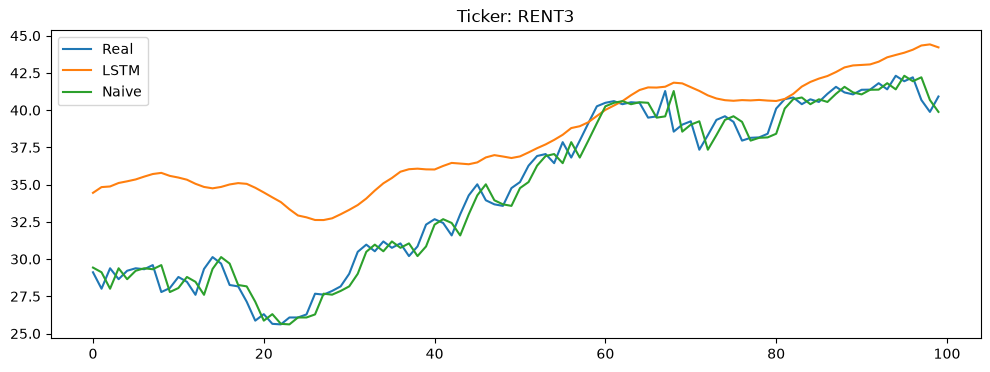

 25%|██▌       | 1/4 [02:36<07:50, 156.79s/it]

Processando para LREN3


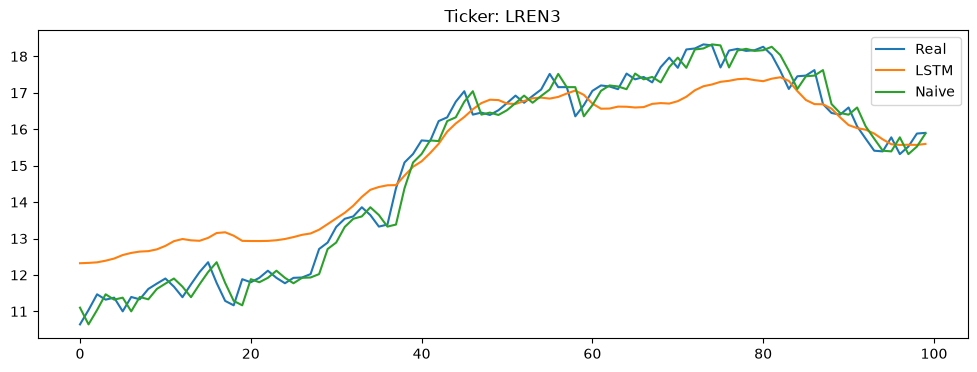

 50%|█████     | 2/4 [03:31<03:13, 96.98s/it] 

Processando para SMFT3


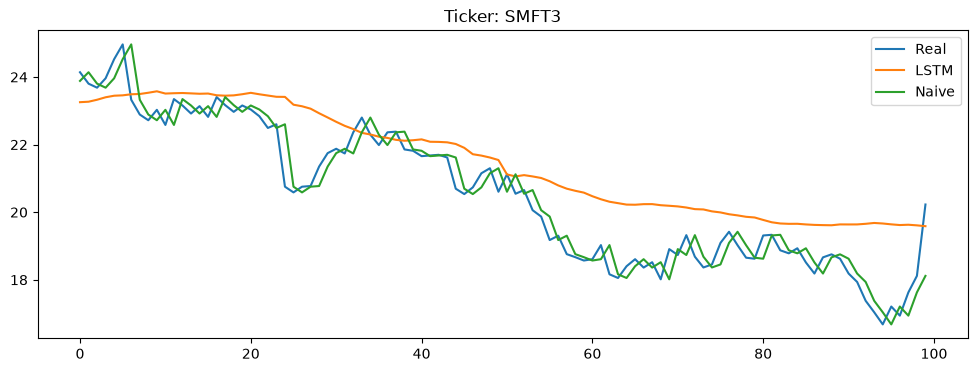

 75%|███████▌  | 3/4 [04:40<01:23, 83.99s/it]

Processando para ABEV3


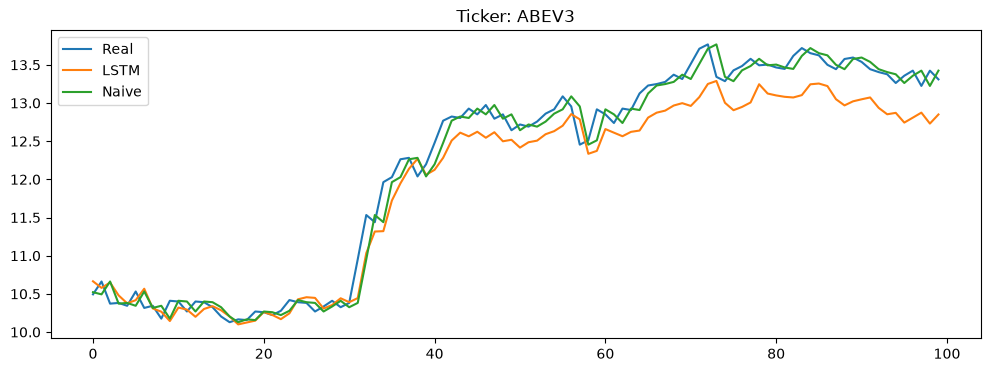

100%|██████████| 4/4 [06:05<00:00, 91.25s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
3,ABEV3,12.42,12.29,1.57,12.60,0.32,0.43,2.35,2.39,0.93,0.14,0.22,1.04,-0.98,2.61,3.44,False
2,SMFT3,18.75,19.32,3.83,20.42,1.05,1.26,5.44,5.24,0.60,0.37,0.50,1.85,-1.51,5.61,6.74,False
1,LREN3,19.60,17.86,6.84,34.89,0.93,1.06,6.62,6.37,0.57,0.27,0.35,1.85,-2.07,4.75,5.43,False
0,RENT3,36.56,39.26,14.61,39.95,2.90,3.46,8.25,7.74,0.69,0.74,1.00,1.88,-2.47,7.93,9.46,False


In [10]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df.dropna()
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss_mse']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v
    recurrent_dropout = 0

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # Divisão temporal ANTES do scaler (evita data leakage)
    n = len(data)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    scaler = RobustScaler()
    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    X_train, y_train = build_lstm_sequences(window_size, train_scaled)
    X_valid, y_valid = build_lstm_sequences(window_size, valid_scaled)
    X_test, y_test = build_lstm_sequences(window_size, test_scaled)

    model = generate_lstm_model(units_1, dropout, units_2, learning_rate, recurrent_dropout, l2, n_dense, dense_units, optimizer, X_train)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=1000,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True)],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    model.save(f"models/lstm_{ticker}_4.keras")

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

    plt.figure(figsize=(12,4))

    plt.plot(real[:100], label="Real")
    plt.plot(pred[:100], label="LSTM")
    plt.plot(naive[:100], label="Naive")
    plt.title(f'Ticker: {ticker}')

    plt.legend()
    plt.show()

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
resultado_final.to_excel(
    "dados/refined/resultado_modelos_lstm_4.xlsx",
    index=False
)

In [ ]:
pd.read_excel("dados/refined/resultado_modelos_lstm_3.xlsx")

,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
0,ABEV3,12.42,12.29,1.57,12.60,0.23,0.37,1.70,1.73,0.95,0.14,0.22,1.04,-0.72,1.87,2.99,False
1,SMFT3,18.75,19.32,3.83,20.42,1.20,1.46,6.24,5.99,0.47,0.37,0.50,1.85,-1.91,6.38,7.80,False
2,LREN3,19.60,17.86,6.84,34.89,0.89,1.07,6.36,6.10,0.56,0.27,0.35,1.85,-2.10,4.55,5.47,False
3,RENT3,36.56,39.26,14.61,39.95,3.71,4.34,10.51,9.76,0.52,0.74,1.00,1.88,-3.35,10.14,11.86,False
